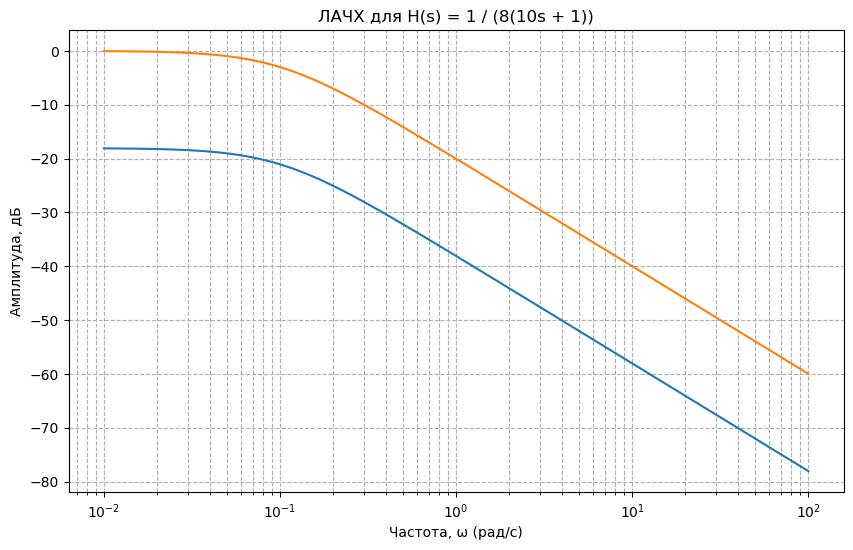

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Частотный диапазон
omega = np.logspace(-2, 2, 400)

# Передаточная функция
H =  1 / (8 * (10 * 1j * omega + 1))
H2 = 1 / (    (10 * 1j * omega + 1))

# Модуль передаточной функции
magnitude = np.abs(H)
magnitude2 = np.abs(H2)

# Преобразование в децибелы
magnitude_db = 20 * np.log10(magnitude)
magnitude2_db = 20 * np.log10(magnitude2)
T = 10
w = omega
# magnitude_db = 20 * np.log10(1/8) - 20 *np.log10((np.sqrt(1 / (T**2 * w**2 + 1))))

# print(20 * np.log10(1/8))
# print(magnitude_db)
# Построение графика
plt.figure(figsize=(10, 6))
plt.semilogx(omega, magnitude_db)
plt.semilogx(omega, magnitude2_db)
plt.title('ЛАЧХ для H(s) = 1 / (8(10s + 1))')
plt.xlabel('Частота, ω (рад/с)')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.show()


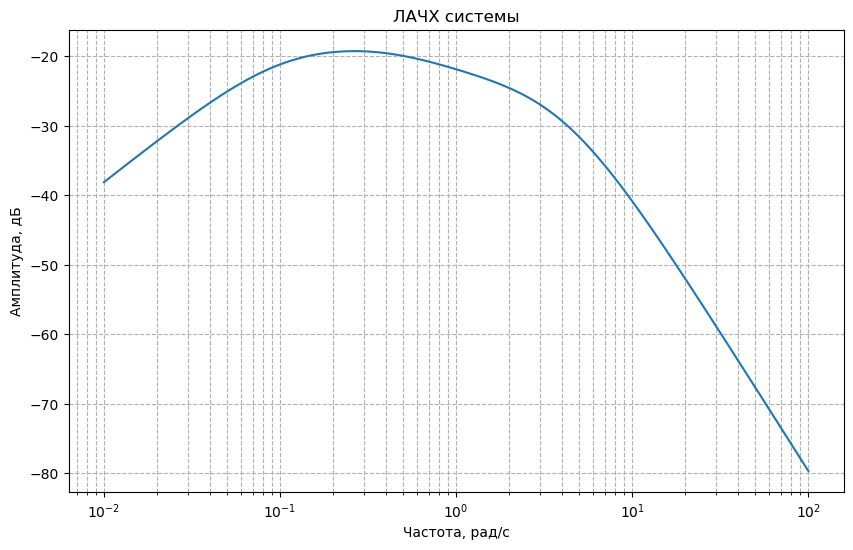

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Определение передаточной функции
num = [1, 1, 0, 0]  # числитель: p^2 (p + 1)
den = np.polymul([8, 0], np.polymul([10, 1], np.polymul([0.3, 1], [0.04, 0.2, 0.1])))  # знаменатель: 8(10p + 1)(0.3p + 1)(0.04p^2 + 0.2p + 0.1)

# Создание объекта передаточной функции
sys = signal.TransferFunction(num, den)

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Построение ЛАЧХ
w, mag, phase = signal.bode(sys, w)

# Построение графика ЛАЧХ
plt.figure(figsize=(10, 6))
plt.semilogx(w, mag)  # логарифмический масштаб по оси x
plt.title('ЛАЧХ системы')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.show()


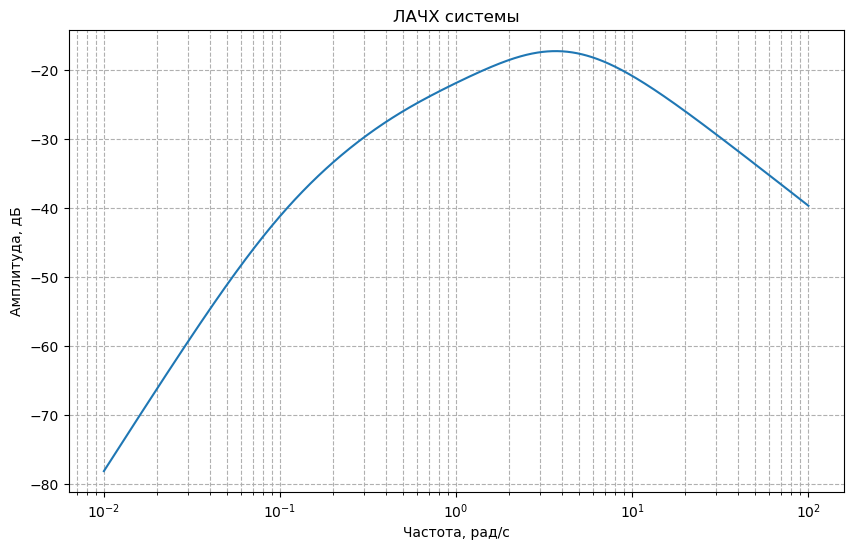

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = p**2 * (p + 1)
    den = 8 * (10*p + 1) * (0.3*p + 1) * (0.04*p**2 + 0.2*p + 0.1)
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(10, 6))
plt.semilogx(w, mag_db)  # логарифмический масштаб по оси x
plt.title('ЛАЧХ системы')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.show()


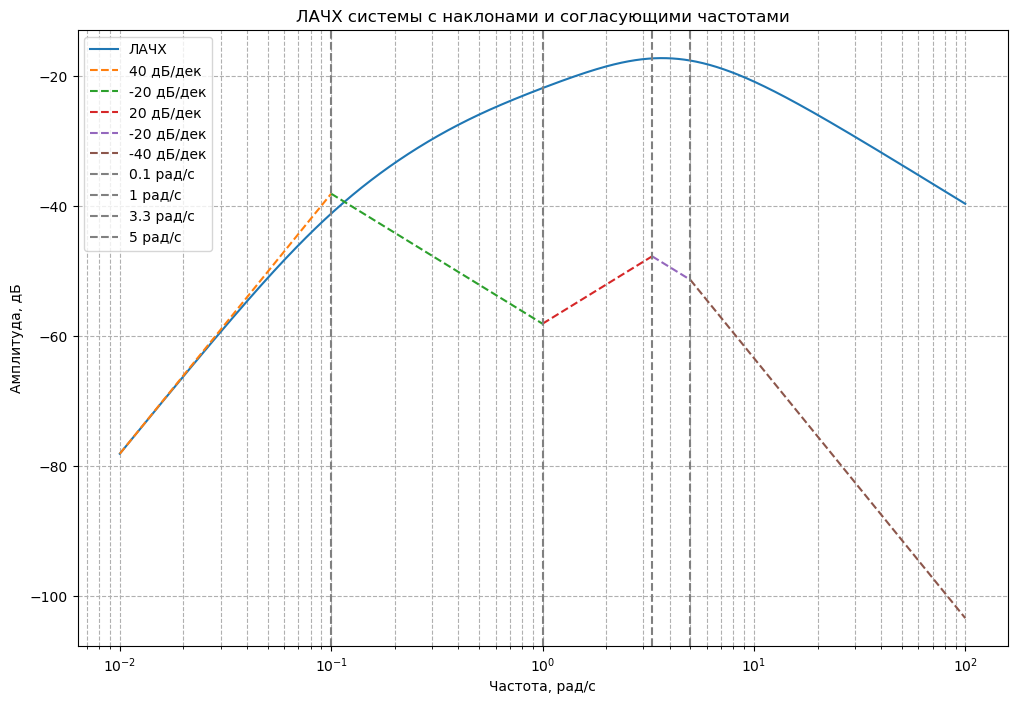

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = p**2 * (p + 1)
    den = 8 * (10*p + 1) * (0.3*p + 1) * (0.04*p**2 + 0.2*p + 0.1)
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(12, 8))
plt.semilogx(w, mag_db, label='ЛАЧХ')  # логарифмический масштаб по оси x

# Согласующие частоты
freqs = [0.1, 1, 3.3, 5]

# Наклоны на участках
slopes = [40, -20, 20, -20, -40]

# Начальная точка для наклонов
start_point = mag_db[0]

# Добавление приблизительных наклонов
for i in range(len(freqs) + 1):
    if i == 0:
        start_freq = w[0]
        end_freq = freqs[i]
    elif i == len(freqs):
        start_freq = freqs[i - 1]
        end_freq = w[-1]
    else:
        start_freq = freqs[i - 1]
        end_freq = freqs[i]

    start_mag = start_point
    end_mag = start_mag + slopes[i] * np.log10(end_freq / start_freq)

    plt.plot([start_freq, end_freq], [start_mag, end_mag], '--', label=f'{slopes[i]} дБ/дек')

    start_point = end_mag

# Добавление вертикальных линий в точках согласующих частот
for freq in freqs:
    plt.axvline(freq, color='gray', linestyle='--', label=f'{freq} рад/с')

# Настройка графика
plt.title('ЛАЧХ системы с наклонами и согласующими частотами')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


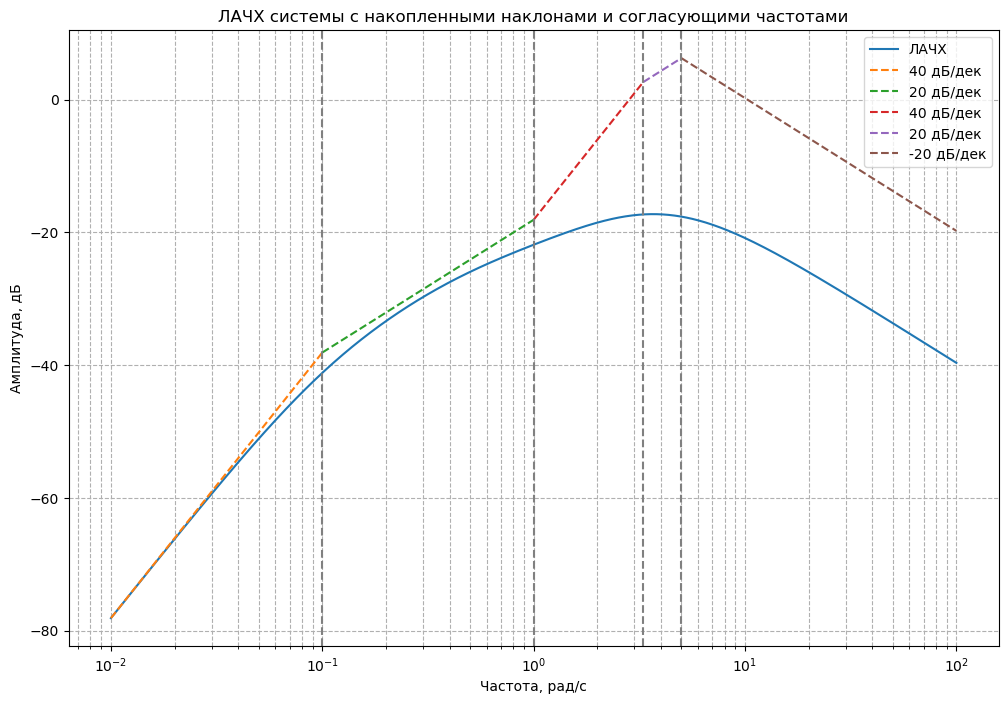

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = p**2 * (p + 1)
    den = 8 * (10*p + 1) * (0.3*p + 1) * (0.04*p**2 + 0.2*p + 0.1)
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(12, 8))
plt.semilogx(w, mag_db, label='ЛАЧХ')  # логарифмический масштаб по оси x

# Согласующие частоты
freqs = [0.1, 1, 3.3, 5]

# Наклоны на участках
slopes = [40, -20, 20, -20, -40]

# Начальная точка для наклонов
start_point = mag_db[0]
cumulative_slope = 0

# Добавление приблизительных наклонов
for i in range(len(freqs) + 1):
    if i == 0:
        start_freq = w[0]
        end_freq = freqs[i]
    elif i == len(freqs):
        start_freq = freqs[i - 1]
        end_freq = w[-1]
    else:
        start_freq = freqs[i - 1]
        end_freq = freqs[i]

    cumulative_slope += slopes[i]
    start_mag = start_point
    end_mag = start_mag + cumulative_slope * np.log10(end_freq / start_freq)

    plt.plot([start_freq, end_freq], [start_mag, end_mag], '--', label=f'{cumulative_slope} дБ/дек')

    start_point = end_mag

# Добавление вертикальных линий в точках согласующих частот
for freq in freqs:
    plt.axvline(freq, color='gray', linestyle='--')

# Настройка графика
plt.title('ЛАЧХ системы с накопленными наклонами и согласующими частотами')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


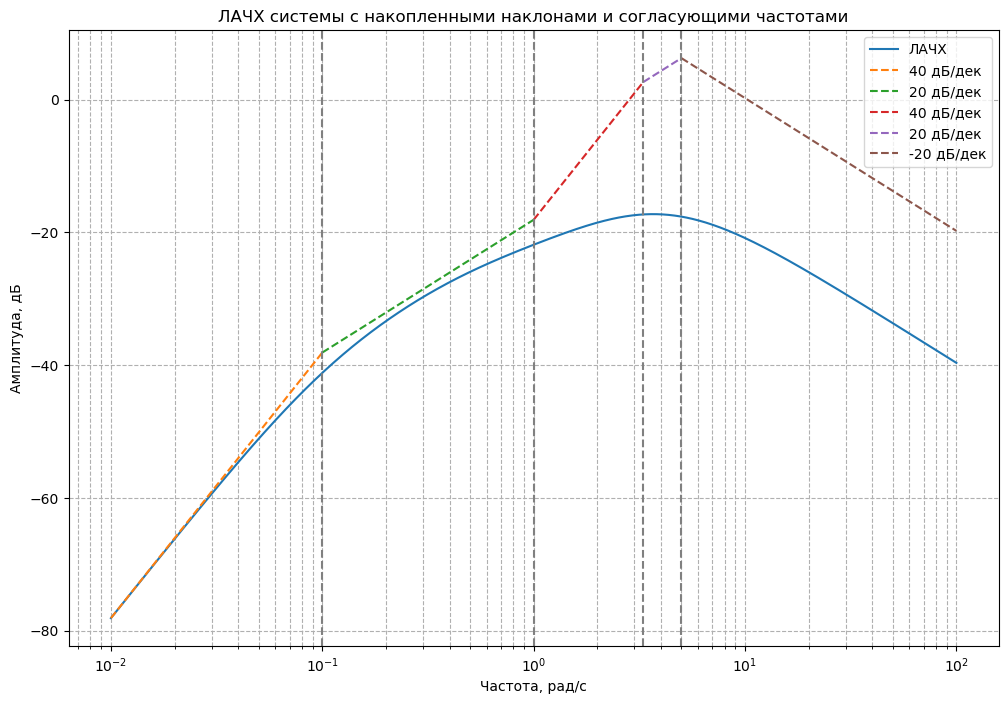

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = p**2 * (p + 1)
    den = 8 * (10*p + 1) * (0.3*p + 1) * (0.04*p**2 + 0.2*p + 0.1)
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(12, 8))
plt.semilogx(w, mag_db, label='ЛАЧХ')  # логарифмический масштаб по оси x

# Согласующие частоты
freqs = [0.1, 1, 3.3, 5]

# Наклоны на участках
slopes = [40, -20, 20, -20, -40]

# Начальная точка для наклонов
start_point = mag_db[0]
cumulative_slope = 0

# Добавление приблизительных наклонов
for i in range(len(freqs) + 1):
    if i == 0:
        start_freq = w[0]
        end_freq = freqs[i]
    elif i == len(freqs):
        start_freq = freqs[i - 1]
        end_freq = w[-1]
    else:
        start_freq = freqs[i - 1]
        end_freq = freqs[i]

    cumulative_slope += slopes[i]
    start_mag = start_point
    end_mag = start_mag + cumulative_slope * np.log10(end_freq / start_freq)

    plt.plot([start_freq, end_freq], [start_mag, end_mag], '--', label=f'{cumulative_slope} дБ/дек')

    start_point = end_mag

# Добавление вертикальных линий в точках согласующих частот
for freq in freqs:
    plt.axvline(freq, color='gray', linestyle='--')

# Настройка графика
plt.title('ЛАЧХ системы с накопленными наклонами и согласующими частотами')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


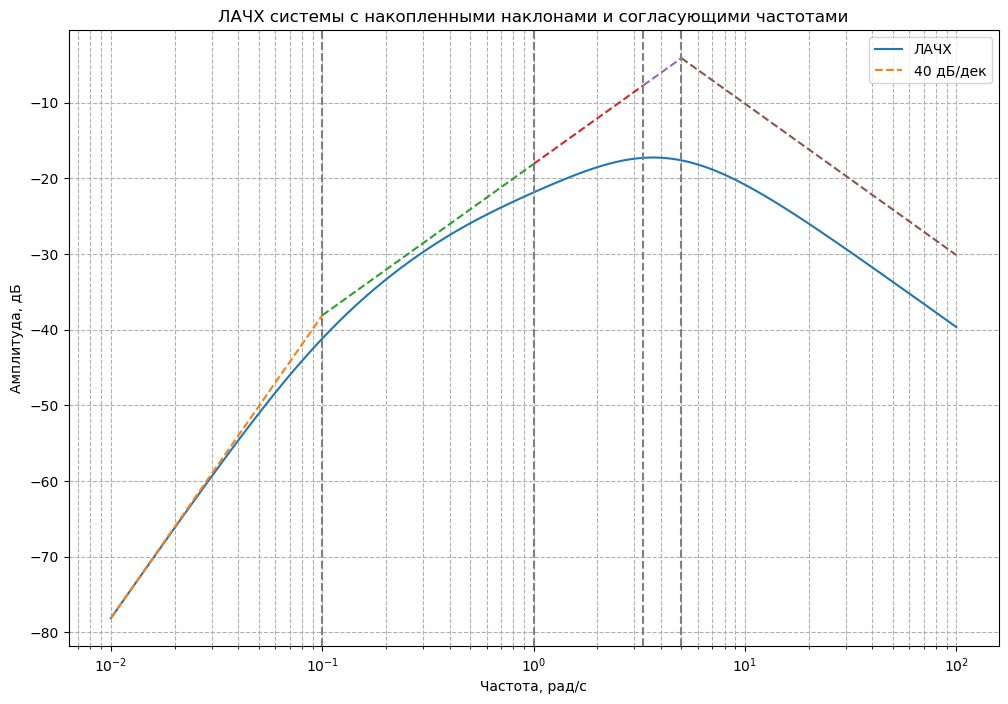

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = p**2 * (p + 1)
    den = 8 * (10*p + 1) * (0.3*p + 1) * (0.04*p**2 + 0.2*p + 0.1)
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(12, 8))
plt.semilogx(w, mag_db, label='ЛАЧХ')  # логарифмический масштаб по оси x

# Согласующие частоты
freqs = [0.1, 1, 3.3, 5]

# Наклоны на участках
# slopes = [40, -20, 0, -20, -40]
# slopes = [40, -20, 0, -20, -20]
# slopes = [40, -20, -0, -0, -40]
slopes = [40, -20, 0, 0, -40]

# Начальная точка для наклонов
start_point = mag_db[0]
cumulative_slope = 0

# Добавление приблизительных наклонов
for i in range(len(freqs) + 1):
    if i == 0:
        start_freq = w[0]
        end_freq = freqs[i]
    elif i == len(freqs):
        start_freq = freqs[i - 1]
        end_freq = w[-1]
    else:
        start_freq = freqs[i - 1]
        end_freq = freqs[i]

    cumulative_slope += slopes[i]
    start_mag = start_point
    end_mag = start_mag + cumulative_slope * np.log10(end_freq / start_freq)

    plt.plot([start_freq, end_freq], [start_mag, end_mag], '--', label=f'{cumulative_slope} дБ/дек' if i == 0 else "")

    start_point = end_mag

# Добавление вертикальных линий в точках согласующих частот
for freq in freqs:
    plt.axvline(freq, color='gray', linestyle='--')

# Настройка графика
plt.title('ЛАЧХ системы с накопленными наклонами и согласующими частотами')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.legend()

# ######################################################
# from scipy import signal

# # Определение передаточной функции
# num = [1, 1, 0, 0]  # числитель: p^2 (p + 1)
# den = np.polymul([8, 0], np.polymul([10, 1], np.polymul([0.3, 1], [0.04, 0.2, 0.1])))  # знаменатель: 8(10p + 1)(0.3p + 1)(0.04p^2 + 0.2p + 0.1)

# # Создание объекта передаточной функции
# sys = signal.TransferFunction(num, den)

# # Определение диапазона частот
# w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# # Построение ЛАЧХ
# w, mag, phase = signal.bode(sys, w)

# # Построение графика ЛАЧХ
# plt.semilogx(w, mag)  # логарифмический масштаб по оси x
# plt.show()


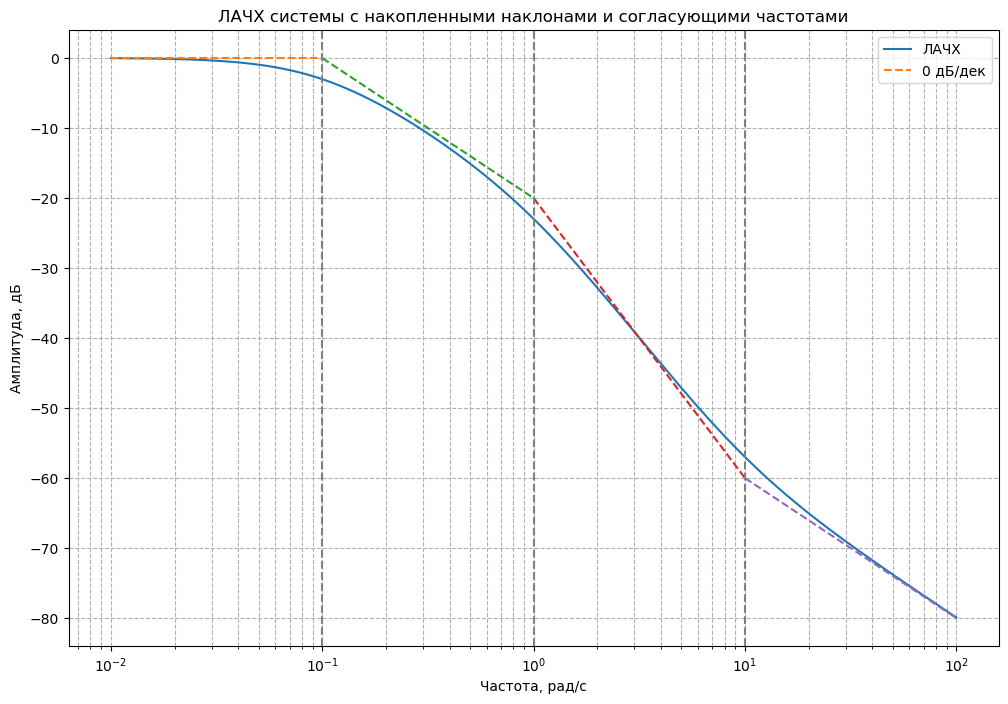

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = 0.1 * p + 1
    den = (p + 1) * (10 * p + 1)
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(12, 8))
plt.semilogx(w, mag_db, label='ЛАЧХ')  # логарифмический масштаб по оси x

# Согласующие частоты
freqs = [0.1, 1, 10]

# Наклоны на участках
slopes = [0,- 20, -20, +20]

# Начальная точка для наклонов
start_point = mag_db[0]
cumulative_slope = 0

# Добавление приблизительных наклонов
for i in range(len(freqs) + 1):
    if i == 0:
        start_freq = w[0]
        end_freq = freqs[i]
    elif i == len(freqs):
        start_freq = freqs[i - 1]
        end_freq = w[-1]
    else:
        start_freq = freqs[i - 1]
        end_freq = freqs[i]

    cumulative_slope += slopes[i]
    start_mag = start_point
    end_mag = start_mag + cumulative_slope * np.log10(end_freq / start_freq)

    plt.plot([start_freq, end_freq], [start_mag, end_mag], '--', label=f'{cumulative_slope} дБ/дек' if i == 0 else "")

    start_point = end_mag

# Добавление вертикальных линий в точках согласующих частот
for freq in freqs:
    plt.axvline(freq, color='gray', linestyle='--')

# Настройка графика
plt.title('ЛАЧХ системы с накопленными наклонами и согласующими частотами')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


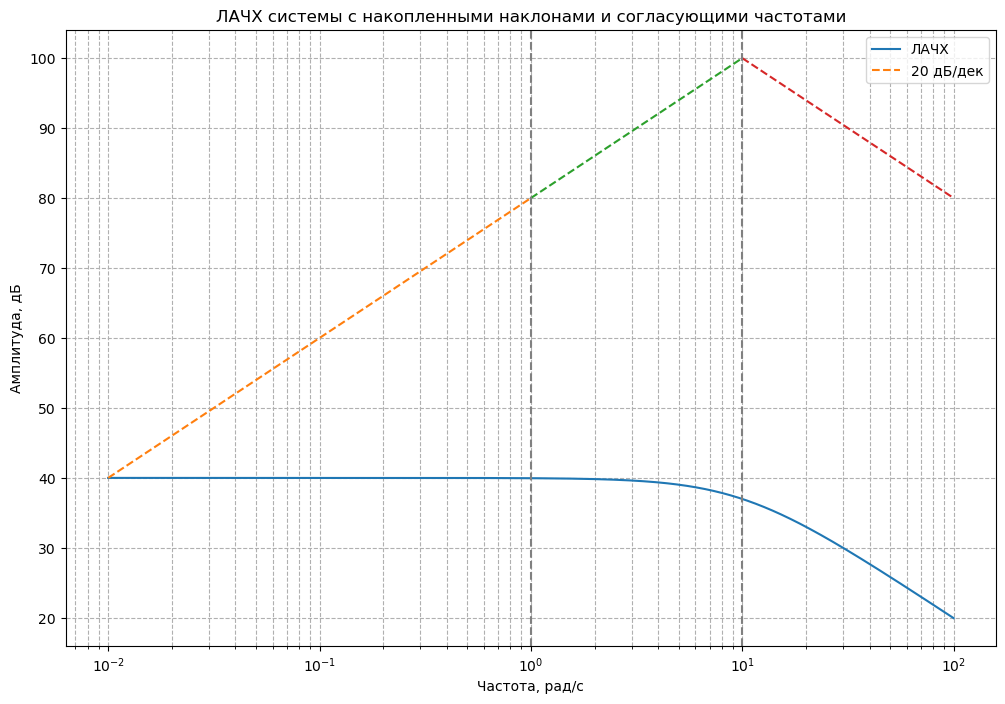

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Определение передаточной функции
def transfer_function(p):
    num = 10 * p
    den = 0.01 * p**2 + 0.1 * p
    return num / den

# Определение диапазона частот
w = np.logspace(-2, 2, 1000)  # от 0.01 до 100 рад/с

# Вычисление АЧХ как модуль передаточной функции
h = np.abs(transfer_function(1j * w))

# Преобразование амплитуды в децибелы
mag_db = 20 * np.log10(h)

# Построение графика ЛАЧХ
plt.figure(figsize=(12, 8))
plt.semilogx(w, mag_db, label='ЛАЧХ')  # логарифмический масштаб по оси x

# Согласующие частоты
freqs = [1, 10]

# Наклоны на участках
slopes = [20, 0, -40]

# Начальная точка для наклонов
start_point = mag_db[0]
cumulative_slope = 0

# Добавление приблизительных наклонов
for i in range(len(freqs) + 1):
    if i == 0:
        start_freq = w[0]
        end_freq = freqs[i]
    elif i == len(freqs):
        start_freq = freqs[i - 1]
        end_freq = w[-1]
    else:
        start_freq = freqs[i - 1]
        end_freq = freqs[i]

    cumulative_slope += slopes[i]
    start_mag = start_point
    end_mag = start_mag + cumulative_slope * np.log10(end_freq / start_freq)

    plt.plot([start_freq, end_freq], [start_mag, end_mag], '--', label=f'{cumulative_slope} дБ/дек' if i == 0 else "")

    start_point = end_mag

# Добавление вертикальных линий в точках согласующих частот
for freq in freqs:
    plt.axvline(freq, color='gray', linestyle='--')

# Настройка графика
plt.title('ЛАЧХ системы с накопленными наклонами и согласующими частотами')
plt.xlabel('Частота, рад/с')
plt.ylabel('Амплитуда, дБ')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()
